# Modul 2 – Linear Classifier (SGD From Scratch)
Google Colab Notebook

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Upload Dataset train.csv

In [25]:
from google.colab import files
uploaded = files.upload()

Saving train.csv to train (2).csv


In [26]:
df = pd.read_csv('train.csv')
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


## Ambil Fitur dan Label

In [27]:
X = df[['ram','battery_power']].values
y = df['price_range'].values

## Normalisasi

In [28]:
X = (X - X.min(axis=0)) / (X.max(axis=0) - X.min(axis=0))

## One Hot Encoding

In [29]:
num_classes = 4
def one_hot(y, num_classes):
    oh = np.zeros((len(y), num_classes))
    oh[np.arange(len(y)), y] = 1
    return oh
Y = one_hot(y, num_classes)

## Softmax & Cross Entropy

In [30]:
def softmax(z):
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z)

def cross_entropy(y_true, y_pred):
    return -np.sum(y_true * np.log(y_pred + 1e-9))

## Inisialisasi Parameter

In [31]:
np.random.seed(42)
D = 2
V = 4
W = np.random.randn(V, D)
b = np.zeros(V)

## Training SGD

In [32]:
lr = 0.05
epochs = 30
loss_history = []

for epoch in range(epochs):
    total_loss = 0
    for i in range(len(X)):
        xi = X[i]
        yi = Y[i]
        z = W @ xi + b
        y_pred = softmax(z)
        loss = cross_entropy(yi, y_pred)
        total_loss += loss
        error = y_pred - yi
        for c in range(V):
            W[c] -= lr * error[c] * xi
            b[c] -= lr * error[c]
    loss_history.append(total_loss/len(X))
    print(f'Epoch {epoch+1} Loss: {loss_history[-1]:.4f}')

Epoch 1 Loss: 1.0472
Epoch 2 Loss: 0.8191
Epoch 3 Loss: 0.7322
Epoch 4 Loss: 0.6797
Epoch 5 Loss: 0.6429
Epoch 6 Loss: 0.6153
Epoch 7 Loss: 0.5934
Epoch 8 Loss: 0.5756
Epoch 9 Loss: 0.5607
Epoch 10 Loss: 0.5480
Epoch 11 Loss: 0.5370
Epoch 12 Loss: 0.5274
Epoch 13 Loss: 0.5189
Epoch 14 Loss: 0.5114
Epoch 15 Loss: 0.5046
Epoch 16 Loss: 0.4985
Epoch 17 Loss: 0.4929
Epoch 18 Loss: 0.4878
Epoch 19 Loss: 0.4832
Epoch 20 Loss: 0.4789
Epoch 21 Loss: 0.4750
Epoch 22 Loss: 0.4713
Epoch 23 Loss: 0.4680
Epoch 24 Loss: 0.4648
Epoch 25 Loss: 0.4619
Epoch 26 Loss: 0.4591
Epoch 27 Loss: 0.4566
Epoch 28 Loss: 0.4542
Epoch 29 Loss: 0.4519
Epoch 30 Loss: 0.4497


## Plot Loss

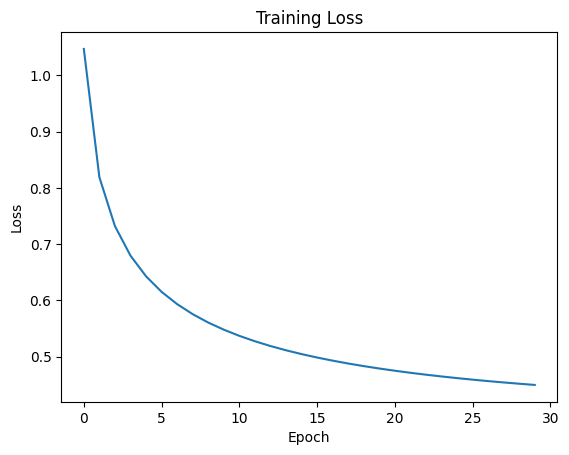

In [33]:
plt.plot(loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

## Decision Boundary

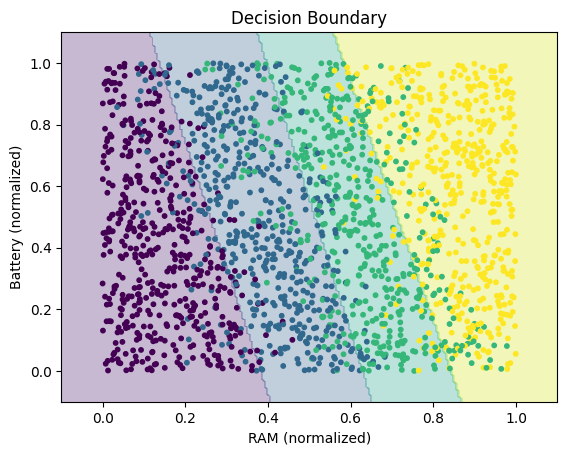

In [34]:
x_min, x_max = X[:,0].min()-0.1, X[:,0].max()+0.1
y_min, y_max = X[:,1].min()-0.1, X[:,1].max()+0.1
xx, yy = np.meshgrid(np.linspace(x_min,x_max,200), np.linspace(y_min,y_max,200))
grid = np.c_[xx.ravel(), yy.ravel()]
preds = []
for g in grid:
    z = W @ g + b
    preds.append(np.argmax(softmax(z)))
Z = np.array(preds).reshape(xx.shape)
plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, s=10)
plt.xlabel('RAM (normalized)')
plt.ylabel('Battery (normalized)')
plt.title('Decision Boundary')
plt.show()